## INSTALASI LIBRARY

Kita perlu menginstal Sastrawi untuk stemming Bahasa Indonesia dan WordCloud untuk visualisasi EDA.
```python
!pip install Sastrawi wordcloud
```

## IMPORT & PERSIAPAN AWAL

Mengimpor semua library yang dibutuhkan

In [1]:
import re, os, io, nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer


## Stopword Removal and Stemmer

In [2]:
# Download NLTK Stopwords
# (Hanya perlu dijalankan sekali)
nltk.download('stopwords')

# Persiapan Stemmer (Sastrawi)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Persiapan Stopwords (NLTK Bahasa Indonesia)
list_stopwords = stopwords.words('indonesian')

# --- Hapus kata-kata yang mungkin penting untuk sentimen ---
# (Contoh: 'tidak', 'kurang'. Anda bisa tambahkan/kurangi)
kata_penting = {'tidak', 'kurang', 'jangan', 'bukan', 'tetapi'}
list_stopwords = [stopword for stopword in list_stopwords if stopword not in kata_penting]

# --- Tambah stopwords manual jika perlu ---
list_stopwords.extend(["yg", "dg", "rt", "dgn", "ny", "d", 'klo', 'kalo',
                       'amp', 'biar', 'bikin', 'bilang', 'gak', 'ga', 'krn',
                       'nya', 'nih', 'sih', 'si', 'tau', 'tdk', 'tuh', 'utk',
                       'ya', 'jd', 'jgn', 'sdh', 'aja', 'n', 't', 'wkwk', 'wkwkwk',
                       'klw', 'jln', 'dri', 'ke', 'di'])

set_stopwords = set(list_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## Load Data

In [3]:
df = pd.read_csv('data/csv/all-task-3-detailed-reviews.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6622 entries, 0 to 6621
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             6622 non-null   object 
 1   place_name                           6622 non-null   object 
 2   review_id                            6622 non-null   object 
 3   review_link                          6622 non-null   object 
 4   name                                 6622 non-null   object 
 5   reviewer_id                          6622 non-null   object 
 6   reviewer_profile                     6622 non-null   object 
 7   rating                               6622 non-null   int64  
 8   review_text                          3455 non-null   object 
 9   published_at                         6622 non-null   object 
 10  published_at_date                    6622 non-null   object 
 11  response_from_owner_text      

## DATA CLEANING & PERSIAPAN PREPROCESSING

In [4]:
# 1. Menghapus ulasan yang kosong (NaN)
print(f"Jumlah data awal: {len(df)}")
df.dropna(subset=['review_text'], inplace=True)
print(f"Jumlah data setelah dibersihkan (review_text tidak kosong): {len(df)}")

# 2. Memilih kolom yang relevan
df_processed = df[['review_text', 'rating']].copy()

Jumlah data awal: 6622
Jumlah data setelah dibersihkan (review_text tidak kosong): 3455


In [10]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3455 entries, 0 to 6620
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   review_text          3455 non-null   object
 1   rating               3455 non-null   int64 
 2   cleaned_tokens       3455 non-null   object
 3   cleaned_text_string  3455 non-null   object
dtypes: int64(1), object(3)
memory usage: 135.0+ KB


## PREPROCESSING

In [5]:
def preprocess_text(text):
    # 1. Case Folding
    text = text.lower()

    # 2. Cleaning (Hapus angka, tanda baca, dll)
    text = re.sub(r'\[.*?\]', '', text)          # Hapus teks dalam tanda kurung
    text = re.sub(r'\W', ' ', text)             # Hapus karakter non-word (tanda baca dll)
    text = re.sub(r'\d+', '', text)             # Hapus angka
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'<.*?>+', '', text)          # Hapus tag HTML
    text = text.strip()                         # Hapus spasi di awal/akhir

    # 3. Tokenisasi (Memecah kalimat jadi kata)
    tokens = text.split()

    # 4. Stopword Removal
    tokens = [word for word in tokens if word not in set_stopwords]

    # 5. Stemming
    # (Kita gabungkan dulu agar Sastrawi lebih cepat)
    text_to_stem = ' '.join(tokens)
    stemmed_text = stemmer.stem(text_to_stem)

    # Tokenisasi ulang setelah stemming
    stemmed_tokens = stemmed_text.split()

    # Mengembalikan daftar token
    return stemmed_tokens

## Executed Preprocessing

In [6]:
print("Memulai proses preprocessing (Case Folding, Cleaning, Tokenisasi, Stopword Removal, Stemming)...")

# Terapkan fungsi ke kolom 'review_text'
df_processed['cleaned_tokens'] = df_processed['review_text'].apply(preprocess_text)

# Buat kolom baru berisi teks bersih (string) untuk TF-IDF dan WordCloud
df_processed['cleaned_text_string'] = df_processed['cleaned_tokens'].apply(lambda x: ' '.join(x))

print("\n--- Preprocessing Selesai ---")
print("Contoh hasil preprocessing:")
print(df_processed[['review_text', 'cleaned_text_string']].head())

Memulai proses preprocessing (Case Folding, Cleaning, Tokenisasi, Stopword Removal, Stemming)...

--- Preprocessing Selesai ---
Contoh hasil preprocessing:
                                         review_text  \
0             Sperti apa ya sekarang akses masuknya?   
3                   Pantai yg indah dengan sunsetnya   
4  Tempat  bagus untuk cari ikan baik ngobor atau...   
5                                       Kahona beach   
6  Untuk Akses Nyampek Kepantainya Bisa Di Lewati...   

                                 cleaned_text_string  
0                                 sperti akses masuk  
3                             pantai indah sunsetnya  
4  bagus cari ikan ngobor ngejaring kampung ku ka...  
5                                       kahona beach  
6             akses nyampek pantai lewatin mobil kak  


## EXPLORATORY DATA ANALYSIS (EDA)

### 1. Visualisasi Distribusi Rating

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9900\2426165205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_processed, x='rating', palette='viridis')


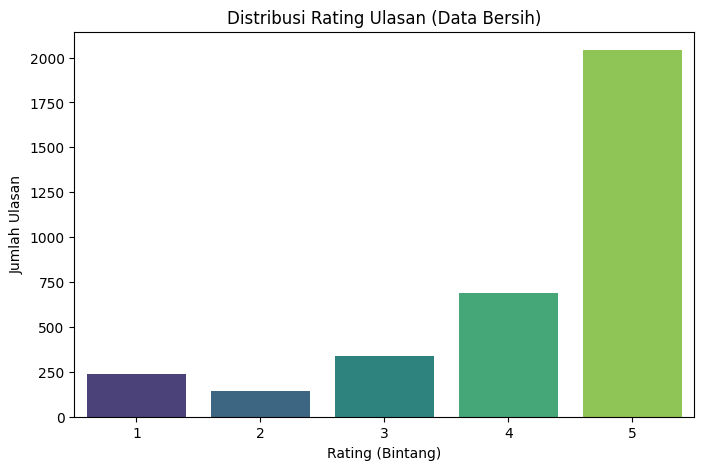

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_processed, x='rating', palette='viridis')
plt.title('Distribusi Rating Ulasan (Data Bersih)')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

### 2. Visualisasi Word Cloud

Membuat Word Cloud dari kata-kata yang paling sering muncul...


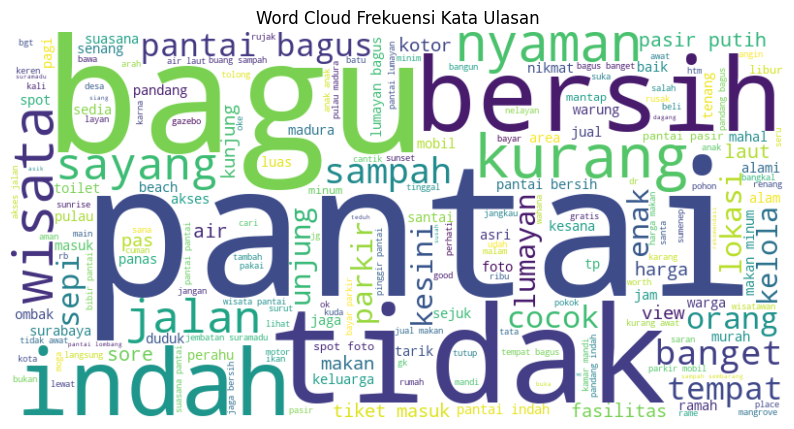

In [8]:
print("Membuat Word Cloud dari kata-kata yang paling sering muncul...")
all_text = ' '.join(df_processed['cleaned_text_string'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Frekuensi Kata Ulasan')
plt.show()

## EKSTRAKSI FITUR (TF-IDF)

Mengubah teks bersih menjadi matriks numerik

In [9]:
# Inisialisasi TfidfVectorizer
# Anda bisa mengatur parameter seperti max_features (jumlah fitur maks)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Terapkan TF-IDF pada kolom teks bersih
tfidf_matrix = tfidf_vectorizer.fit_transform(df_processed['cleaned_text_string'])

# Mendapatkan nama fitur (kata-kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Bentuk Matriks TF-IDF: {tfidf_matrix.shape}")
print(f"Jumlah fitur (kata unik) yang diekstraksi: {len(feature_names)}")
print("\nContoh 10 Fitur Pertama:")
print(feature_names[:10])

Bentuk Matriks TF-IDF: (3455, 5000)
Jumlah fitur (kata unik) yang diekstraksi: 5000

Contoh 10 Fitur Pertama:
['aamiin' 'abad' 'abadi' 'abandoned' 'abang' 'abbiizzz' 'abdi' 'abis'
 'abisss' 'abiz']


Membuat Pie Chart Distribusi Rating...


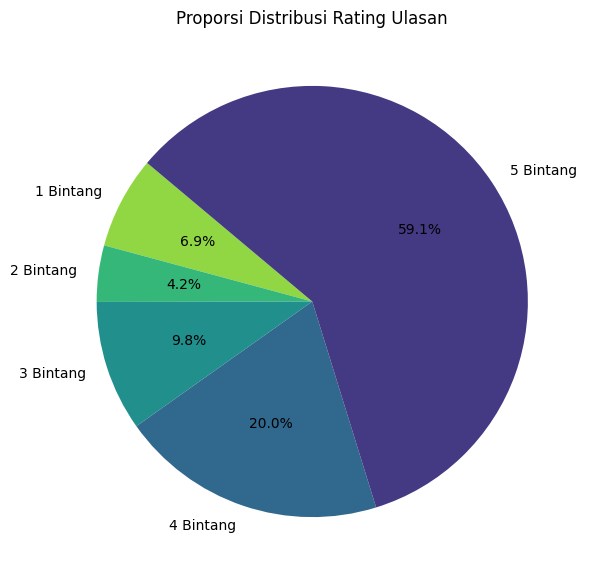

Membuat Bar Chart Top 20 Bigrams (Frasa 2-Kata)...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9900\1046275372.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_bigrams.values, y=top_20_bigrams.index, palette='plasma')


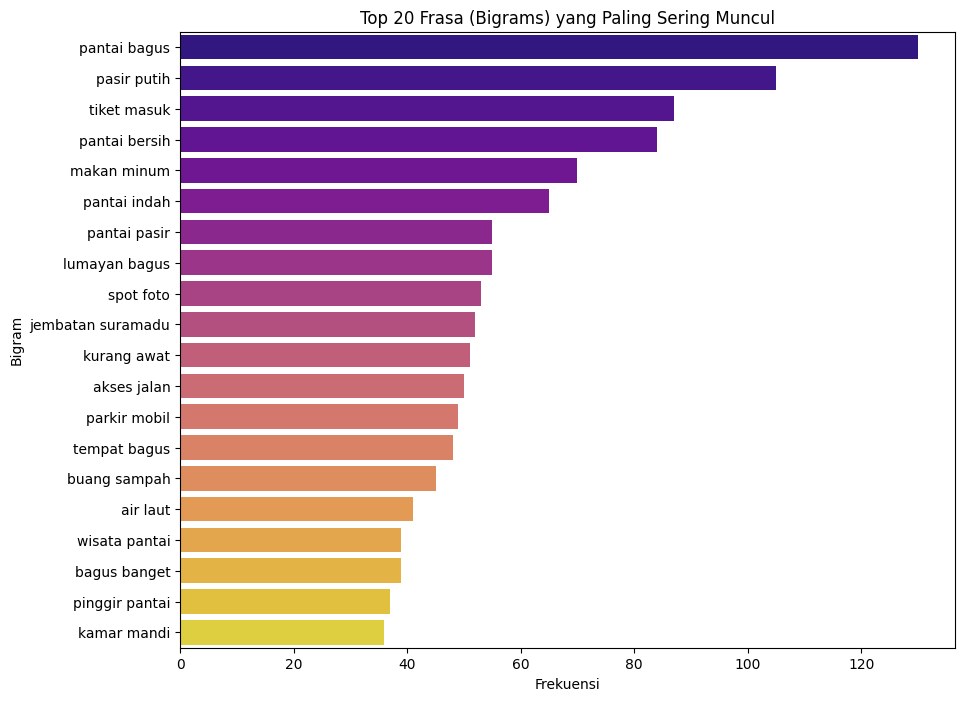

In [11]:
#################################################################
# LANGKAH 9: VISUALISASI TAMBAHAN (dari df_processed)
# (Jalankan ini setelah skrip sebelumnya)
#################################################################
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Pastikan df_processed ada (jika ini sesi baru, jalankan skrip sebelumnya dulu)
if 'df_processed' not in locals():
    print("Error: DataFrame 'df_processed' tidak ditemukan.")
    print("Harap jalankan skrip preprocessing dan EDA sebelumnya terlebih dahulu.")
else:
    # 1. Visualisasi Pie Chart Distribusi Rating
    print("Membuat Pie Chart Distribusi Rating...")
    rating_counts = df_processed['rating'].value_counts().sort_index()

    plt.figure(figsize=(7, 7))
    plt.pie(
        rating_counts,
        labels=rating_counts.index.map(lambda r: f'{r} Bintang'),
        autopct='%1.1f%%',  # Tampilkan persentase
        startangle=140,
        colors=sns.color_palette('viridis_r', n_colors=5)
    )
    plt.title('Proporsi Distribusi Rating Ulasan')
    plt.show()

    # 2. Visualisasi Bar Chart Top N-Grams (Bigrams)
    # Ini membantu menemukan frasa yang sering muncul (aspek)
    print("Membuat Bar Chart Top 20 Bigrams (Frasa 2-Kata)...")

    # Kita gunakan CountVectorizer untuk menghitung N-grams
    # (min_df=5) berarti frasa harus muncul setidaknya 5 kali
    vec_bigrams = CountVectorizer(ngram_range=(2, 2), min_df=5)
    bigram_matrix = vec_bigrams.fit_transform(df_processed['cleaned_text_string'])

    # Buat DataFrame dari hasil bigrams
    bigram_counts = pd.DataFrame(
        bigram_matrix.toarray(),
        columns=vec_bigrams.get_feature_names_out()
    ).sum().sort_values(ascending=False)

    # Ambil Top 20
    top_20_bigrams = bigram_counts.head(20)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_20_bigrams.values, y=top_20_bigrams.index, palette='plasma')
    plt.title('Top 20 Frasa (Bigrams) yang Paling Sering Muncul')
    plt.xlabel('Frekuensi')
    plt.ylabel('Bigram')
    plt.show()

In [ ]:
#################################################################
# LANGKAH 10: VISUALISASI DATA OVERVIEW (Review per Pantai)
# (Memerlukan upload file overview)
#################################################################
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("--- Memulai Visualisasi Data Overview ---")
print("Silakan upload file 'all-task-3-overview.xlsx - Sheet1.csv' Anda...")

# 1. Upload dan Muat Data Overview
try:
    uploaded_overview = files.upload()
    overview_file_name = list(uploaded_overview.keys())[0]
    print(f"File '{overview_file_name}' berhasil di-upload.")

    df_overview = pd.read_csv(io.BytesIO(uploaded_overview[overview_file_name]))

    # 2. Cleaning Data Overview
    print("Membersihkan data overview...")
    # Pilih kolom yang relevan
    df_beach_reviews = df_overview[['name', 'reviews']].copy()

    # Hapus baris yang 'name' atau 'reviews' nya kosong
    df_beach_reviews.dropna(inplace=True)

    # Konversi 'reviews' ke numerik (penting!)
    # errors='coerce' akan mengubah teks non-angka menjadi NaN
    df_beach_reviews['reviews'] = pd.to_numeric(df_beach_reviews['reviews'], errors='coerce')

    # Hapus lagi NaN yang mungkin muncul dari konversi
    df_beach_reviews.dropna(inplace=True)

    # Konversi ke integer
    df_beach_reviews['reviews'] = df_beach_reviews['reviews'].astype(int)

    # 3. Visualisasi Bar Chart Top 10 Pantai
    print("Membuat Bar Chart Top 10 Pantai Berdasarkan Jumlah Review...")

    # Urutkan dan ambil top 10
    top_10_beaches = df_beach_reviews.sort_values(by='reviews', ascending=False).head(10)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=top_10_beaches,
        x='reviews',
        y='name',
        palette='cubehelix'
    )
    plt.title('Top 10 Pantai dengan Jumlah Review Terbanyak')
    plt.xlabel('Jumlah Total Review')
    plt.ylabel('Nama Pantai')
    plt.show()

except Exception as e:
    print(f"Terjadi error: {e}")
    print("Pastikan Anda mengupload file CSV yang benar.")

print("--- Visualisasi Data Overview Selesai ---")